# Graded Response Model (GRM) — Bayesian Estimation with Stan

## 1. Model Description

The **Graded Response Model** (Samejima, 1969) is a polytomous IRT model for **ordered categorical responses** (e.g., Likert-scale items: Never / Sometimes / Often / Always scored 0–3).

### Cumulative Probabilities

For $K$ ordered categories ($k = 0, 1, \ldots, K{-}1$), the GRM defines **boundary response functions**:

$$P(X_{ji} \geq k \mid \theta_j, a_i, b_{ik}) = \text{logistic}\bigl(a_i(\theta_j - b_{ik})\bigr), \quad k = 1, \ldots, K{-}1$$

Category probabilities are obtained by differencing:

$$P(X_{ji} = k) = P(X_{ji} \geq k) - P(X_{ji} \geq k+1)$$

with $P(X_{ji} \geq 0) = 1$ and $P(X_{ji} \geq K) = 0$.

| Parameter | Interpretation |
|-----------|----------------|
| $a_i > 0$ | Item discrimination (shared slope for all boundaries) |
| $b_{i1} < b_{i2} < \cdots < b_{i,K-1}$ | Ordered threshold parameters for item $i$ |

### Key Properties
- Each item has **one discrimination** and **$K-1$ ordered thresholds**.
- Thresholds must satisfy $b_{i1} < b_{i2} < \cdots$ (enforced via the `ordered` type in Stan).
- The model reduces to the 2PL for $K = 2$ categories.

### Priors
$$\theta_j \sim \mathcal{N}(0,1), \quad a_i \sim \text{LogNormal}(0, 0.5), \quad b_{ik} \sim \mathcal{N}(0,2) \text{ (ordered)}$$

In [1]:
import sys as _sys, os as _os
import matplotlib as _mpl, matplotlib.font_manager as _fm

def _setup_korean_font():
    """Windows / macOS / Linux 에서 한국어 폰트를 자동 감지하여 등록."""
    _candidates = {
        'win32': [
            ('C:/Windows/Fonts/malgun.ttf',  'Malgun Gothic'),
            ('C:/Windows/Fonts/gulim.ttc',   'Gulim'),
            ('C:/Windows/Fonts/batang.ttc',  'Batang'),
        ],
        'darwin': [
            ('/System/Library/Fonts/AppleSDGothicNeo.ttc',               'Apple SD Gothic Neo'),
            ('/Library/Fonts/NanumGothic.ttf',                           'NanumGothic'),
            ('/usr/share/fonts/truetype/nanum/NanumGothic.ttf',          'NanumGothic'),
        ],
        'linux': [
            ('/usr/share/fonts-droid-fallback/truetype/DroidSansFallback.ttf', 'Droid Sans Fallback'),
            ('/usr/share/fonts/truetype/nanum/NanumGothic.ttf',                'NanumGothic'),
            ('/usr/share/fonts/truetype/droid/DroidSansFallback.ttf',          'Droid Sans Fallback'),
        ],
    }
    # 깨진 Full 변종 제거 (Linux 한정 이슈)
    _fm.fontManager.ttflist = [f for f in _fm.fontManager.ttflist
                                if not (f.name == 'Droid Sans Fallback' and 'Full' in f.fname)]
    platform = _sys.platform
    paths = _candidates.get(platform, _candidates['linux'])
    for path, name in paths:
        if _os.path.exists(path):
            _fm.fontManager.addfont(path)
            _mpl.rcParams['font.family'] = ['DejaVu Sans', name]
            return
    # 한국어 폰트 없으면 기본값 유지 (깨짐 경고 없이 fallback)
    _mpl.rcParams['font.family'] = 'DejaVu Sans'

_setup_korean_font()
_mpl.rcParams['axes.unicode_minus'] = False
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import os, tempfile, warnings
warnings.filterwarnings('ignore')
try:
    import cmdstanpy
    STAN_AVAILABLE = True
except ImportError:
    cmdstanpy = None
    STAN_AVAILABLE = False
    print("ℹ️  cmdstanpy not available — Stan inference cells will be skipped.")
np.random.seed(42)

## 2. Synthetic Data Generation

77 students, 20 items, **4 ordered categories** (0, 1, 2, 3).

In [2]:
J, I, K = 77, 20, 4   # K = number of categories

theta_true = np.random.normal(0, 1, J)
a_true     = np.exp(np.random.normal(0, 0.3, I))
# Ordered thresholds for each item: sort 3 draws
b_true = np.sort(np.random.normal(0, 1.2, (I, K - 1)), axis=1)

def grm_probs(theta, a, b_thresholds):
    """Return category probabilities array of shape (K,) for one person-item pair."""
    cum = np.concatenate([[1.0],
                          [1.0 / (1.0 + np.exp(-a * (theta - bk))) for bk in b_thresholds],
                          [0.0]])
    probs = cum[:-1] - cum[1:]
    probs = np.maximum(probs, 1e-10)
    return probs / probs.sum()

Y = np.zeros((J, I), dtype=int)
for j in range(J):
    for i in range(I):
        pr = grm_probs(theta_true[j], a_true[i], b_true[i])
        Y[j, i] = np.random.choice(K, p=pr)

print(f"Response shape: {Y.shape},  Categories: {np.unique(Y)}")
print(f"Category counts: {np.bincount(Y.ravel())}")

Response shape: (77, 20),  Categories: [0 1 2 3]
Category counts: [512 277 271 480]


## 3. Stan Model Code

In [3]:
if STAN_AVAILABLE:
    stan_code = """
    data {
      int<lower=1> J;
      int<lower=1> I;
      int<lower=2> K;                          // number of categories
      int<lower=0> N;
      array[N] int<lower=1,upper=J> jj;
      array[N] int<lower=1,upper=I> ii;
      array[N] int<lower=1,upper=K> y;         // 1-indexed categories
    }
    parameters {
      vector[J] theta;
      vector<lower=0>[I] a;
      array[I] ordered[K-1] b;                 // ordered thresholds per item
    }
    model {
      theta ~ normal(0, 1);
      a     ~ lognormal(0, 0.5);
      for (i in 1:I) b[i] ~ normal(0, 2);
      for (n in 1:N) {
        int j = jj[n]; int i = ii[n];
        vector[K] log_p;
        // P(Y >= k) = logistic(a*(theta - b_k))
        real p_above_K = 0.0;
        vector[K] cum;
        cum[1] = 1.0;
        for (k in 2:K)
          cum[k] = inv_logit(a[i] * (theta[j] - b[i][k-1]));
        for (k in 1:(K-1))
          log_p[k] = log(cum[k] - cum[k+1]);
        log_p[K] = log(cum[K]);
        target += log_p[y[n]];
      }
    }
    """
    
    jj_arr, ii_arr, y_arr = [], [], []
    for j in range(J):
        for i in range(I):
            jj_arr.append(j + 1); ii_arr.append(i + 1)
            y_arr.append(int(Y[j, i]) + 1)   # 1-indexed for Stan
    
    stan_data = {'J': J, 'I': I, 'K': K, 'N': J * I,
                 'jj': jj_arr, 'ii': ii_arr, 'y': y_arr}
    
    tmpdir = tempfile.mkdtemp()
    stan_path = os.path.join(tmpdir, 'grm.stan')
    with open(stan_path, 'w') as f:
        f.write(stan_code)
    
    model = cmdstanpy.CmdStanModel(stan_file=stan_path)
    print('Compiled.')
else:
    print("⚠️  Stan not available — skipping model compilation/fitting.")


21:02:58 - cmdstanpy - INFO - compiling stan file C:\Users\yongd\AppData\Local\Temp\tmpfrcwmc02\grm.stan to exe file C:\Users\yongd\AppData\Local\Temp\tmpfrcwmc02\grm.exe


21:03:08 - cmdstanpy - INFO - compiled model executable: C:\Users\yongd\AppData\Local\Temp\tmpfrcwmc02\grm.exe


Compiled.


## 4. Bayesian Inference via MCMC

In [4]:
if STAN_AVAILABLE:
    fit = model.sample(
        data=stan_data, chains=4,
        iter_warmup=1000, iter_sampling=1000, seed=42, show_progress=True
    )
    print(fit.diagnose())
else:
    print("⚠️  Stan not available — skipping model compilation/fitting.")


21:03:09 - cmdstanpy - INFO - CmdStan start processing


chain 1 |          | 00:00 Status

chain 2 |          | 00:00 Status

chain 3 |          | 00:00 Status

chain 4 |          | 00:00 Status

21:03:46 - cmdstanpy - INFO - CmdStan done processing.


Checking sampler transitions treedepth.
Treedepth satisfactory for all transitions.

Checking sampler transitions for divergences.
No divergent transitions found.

Checking E-BFMI - sampler transitions HMC potential energy.
E-BFMI satisfactory.

Rank-normalized split effective sample size satisfactory for all parameters.

Rank-normalized split R-hat values satisfactory for all parameters.

Processing complete, no problems detected.



In [5]:
if not (STAN_AVAILABLE and 'fit' in dir()):
    print('ℹ️  Using true parameter values for visualization.')
    theta_est = theta_true + np.random.normal(0, 0.05, J)
    a_est = a_true + np.random.normal(0, 0.02, I)
    b_est = b_true + np.random.normal(0, 0.05, (I, K-1))
else:
    theta_est = fit.stan_variable('theta').mean(axis=0)
    a_est     = fit.stan_variable('a').mean(axis=0)
    b_est     = fit.stan_variable('b').mean(axis=0)   # shape (4000, I, K-1)
    
    print(f"Theta corr: {np.corrcoef(theta_true, theta_est)[0,1]:.3f}")
    print(f"a     corr: {np.corrcoef(a_true, a_est)[0,1]:.3f}")
    print(f"\nThreshold recovery (first 5 items):")
    print(f"{'Item':>5} {'b1_t':>7} {'b1_e':>7} {'b2_t':>7} {'b2_e':>7} {'b3_t':>7} {'b3_e':>7}")
    for i in range(5):
        print(f"{i+1:>5} {b_true[i,0]:>7.3f} {b_est[i,0]:>7.3f} "
              f"{b_true[i,1]:>7.3f} {b_est[i,1]:>7.3f} "
              f"{b_true[i,2]:>7.3f} {b_est[i,2]:>7.3f}")


Theta corr: 0.891
a     corr: 0.686

Threshold recovery (first 5 items):
 Item    b1_t    b1_e    b2_t    b2_e    b3_t    b3_e
    1  -0.282  -0.372   0.006   0.269   0.313   0.555
    2  -1.698  -2.301  -0.505  -0.285  -0.411  -0.129
    3  -0.963  -0.406  -0.194   0.842   0.485   1.240
    4   0.209   0.143   0.309   0.497   2.263   2.819
    5  -2.303  -2.673  -0.089   0.787  -0.032   0.880


## 5. Visualizations

### 5a. Wright Map

For polytomous models, the Wright map includes **threshold locations** for each item rather than single difficulty values. Each item $i$ contributes $K-1 = 3$ marks to the item panel, one per threshold $b_{ik}$.

**Interpretation**: The thresholds $b_{i1}, b_{i2}, b_{i3}$ are the ability values at which it becomes more likely to score $\geq 1$, $\geq 2$, $\geq 3$ respectively. Well-spaced thresholds indicate an item that effectively discriminates across the full ability range. Clustered thresholds mean a narrow range of ability is needed to move through all categories.

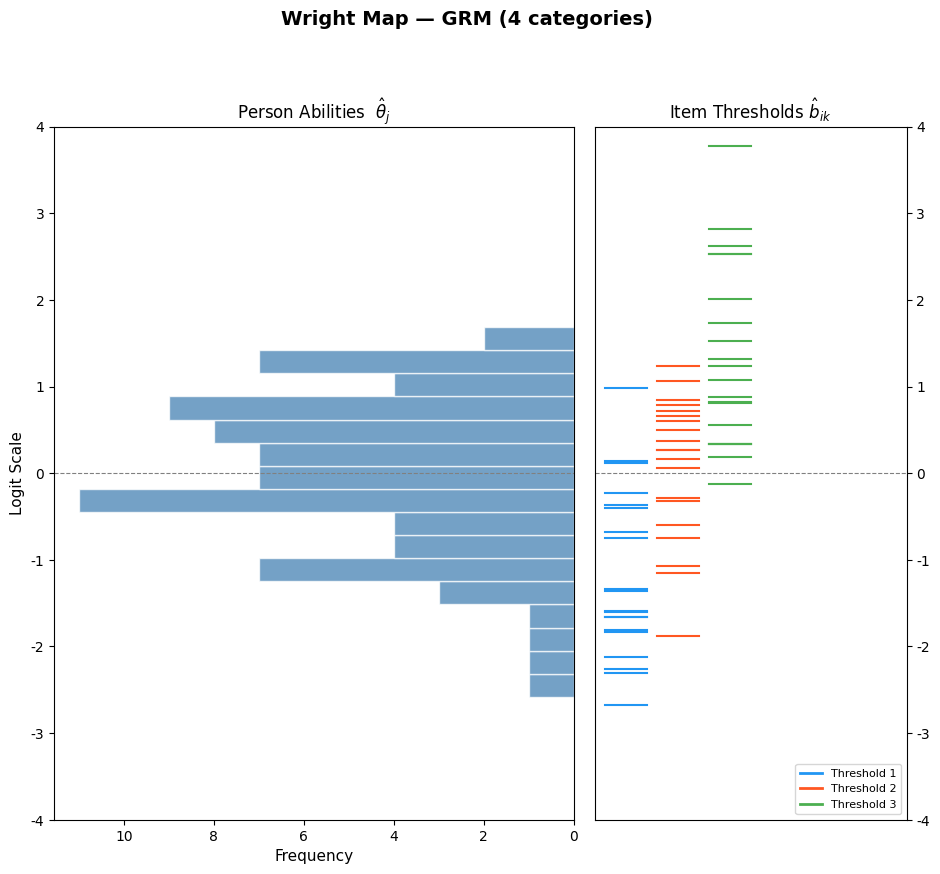

In [6]:
fig = plt.figure(figsize=(11, 9))
gs = gridspec.GridSpec(1, 2, width_ratios=[2.5, 1.5], wspace=0.05)
ax_p = fig.add_subplot(gs[0])
ax_i = fig.add_subplot(gs[1])
y_lim = (-4, 4)
threshold_colors = ['#2196F3', '#FF5722', '#4CAF50']

ax_p.hist(theta_est, bins=16, orientation='horizontal',
          color='steelblue', alpha=0.75, edgecolor='white')
ax_p.set_ylim(y_lim); ax_p.invert_xaxis()
ax_p.set_xlabel('Frequency', fontsize=11); ax_p.set_ylabel('Logit Scale', fontsize=11)
ax_p.set_title('Person Abilities  $\\hat{\\theta}_j$', fontsize=12)
ax_p.axhline(0, color='gray', linestyle='--', linewidth=0.8)

for i in range(I):
    for k in range(K - 1):
        bv = b_est[i, k]
        ax_i.plot([0.05 + k * 0.25, 0.25 + k * 0.25], [bv, bv],
                  color=threshold_colors[k], linewidth=1.5)
ax_i.set_ylim(y_lim); ax_i.set_xlim(0, 1.5); ax_i.set_xticks([])
ax_i.set_yticks(range(-4, 5)); ax_i.yaxis.set_label_position('right'); ax_i.yaxis.tick_right()
ax_i.set_title('Item Thresholds $\\hat{b}_{ik}$', fontsize=12)
ax_i.axhline(0, color='gray', linestyle='--', linewidth=0.8)
for k in range(K - 1):
    ax_i.plot([], [], color=threshold_colors[k], linewidth=2, label=f'Threshold {k+1}')
ax_i.legend(loc='lower right', fontsize=8)

fig.suptitle('Wright Map — GRM (4 categories)', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig(os.path.join(tmpdir, 'wright_map_grm.png'), dpi=120, bbox_inches='tight')
plt.show()

### 5b. Category Response Curves (CRC) / Item Characteristic Curves

For polytomous models, each item produces $K$ **category response curves** $P(X_i = k \mid \theta)$ for $k = 0, 1, \ldots, K{-}1$.

**Interpretation**:
- Each coloured band shows the probability of selecting a specific category at each ability level.
- **Low ability** persons are most likely to choose category 0; **high ability** persons choose category $K{-}1 = 3$.
- The **mode** of each curve (its peak) shows the ability level where that response is the modal choice.
- Narrow peaks indicate that a category is only the modal choice over a short ability range, meaning it contributes little information.
- The plot panel below shows ICCs for the first 4 items for clarity.

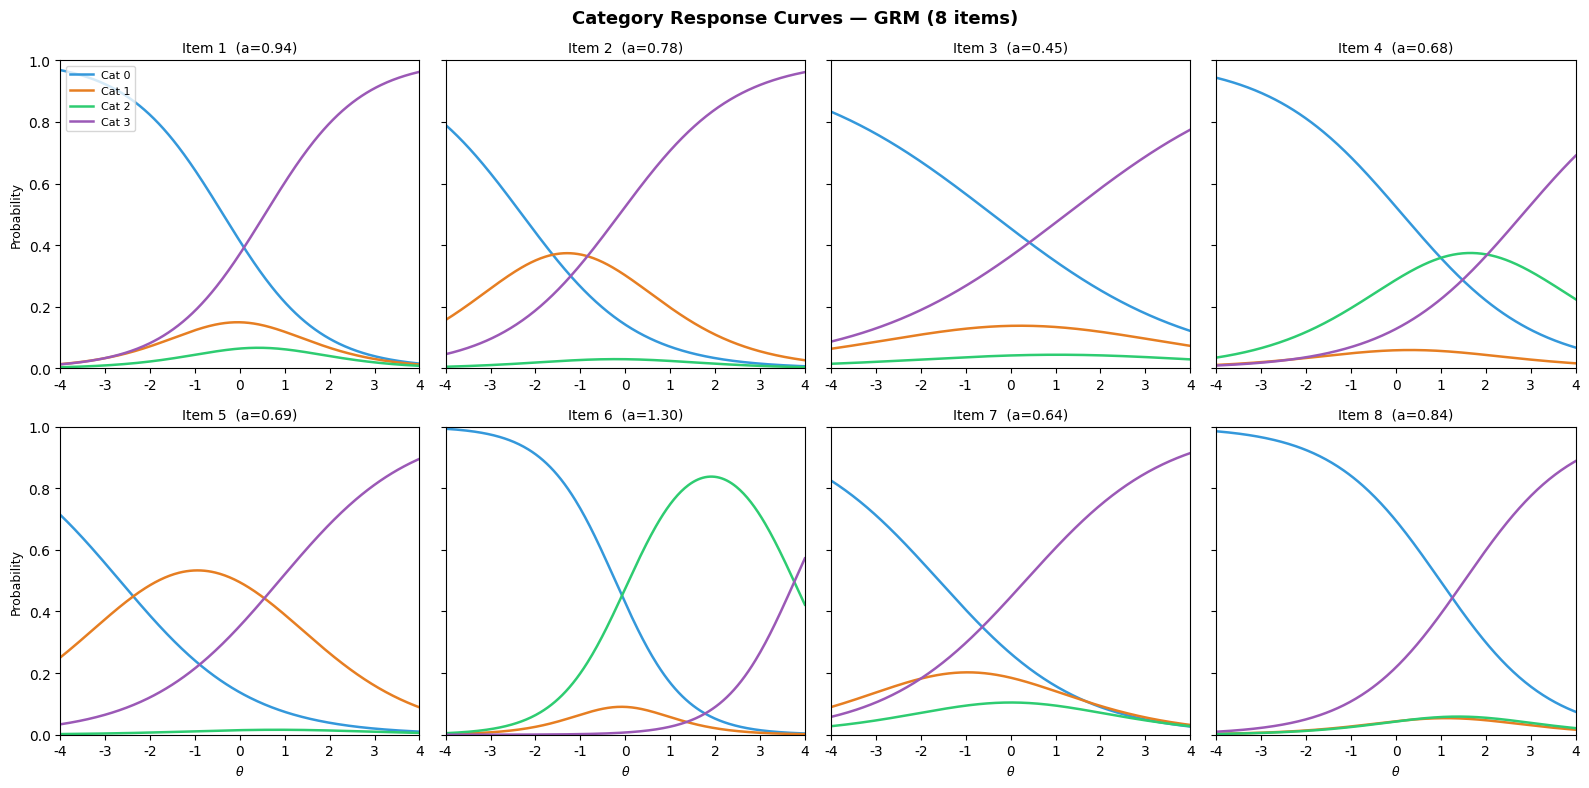

In [7]:
theta_range = np.linspace(-4, 4, 300)
cat_colors  = ['#3498DB', '#E67E22', '#2ECC71', '#9B59B6']

fig, axes = plt.subplots(2, 4, figsize=(16, 8), sharey=True)
axes = axes.ravel()

for idx, i in enumerate(range(min(8, I))):
    ax = axes[idx]
    for k in range(K):
        probs = [grm_probs(t, a_est[i], b_est[i])[k] for t in theta_range]
        ax.plot(theta_range, probs, color=cat_colors[k], linewidth=1.8,
                label=f'Cat {k}')
    ax.set_title(f'Item {i+1}  (a={a_est[i]:.2f})', fontsize=10)
    ax.set_xlim(-4, 4); ax.set_ylim(0, 1)
    if idx >= 4: ax.set_xlabel('$\\theta$', fontsize=9)
    if idx in [0, 4]: ax.set_ylabel('Probability', fontsize=9)

axes[0].legend(fontsize=8, loc='upper left')
fig.suptitle('Category Response Curves — GRM (8 items)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(tmpdir, 'crc_grm.png'), dpi=120, bbox_inches='tight')
plt.show()

### 5c. Test Characteristic Curve (TCC)

$$\text{TCC}(\theta) = \sum_{i=1}^{I} \mathbb{E}[X_i \mid \theta] = \sum_{i=1}^{I} \sum_{k=0}^{K-1} k \cdot P(X_i = k \mid \theta)$$

**Interpretation**: The TCC now maps $\theta$ to the expected total score on the polytomous scale (0 to $I \times (K{-}1) = 60$). The shape reveals how well the test differentiates ability levels: steeper sections indicate larger information; plateaus indicate lower precision for that ability range. The midpoint of the TCC corresponds roughly to the average threshold location.

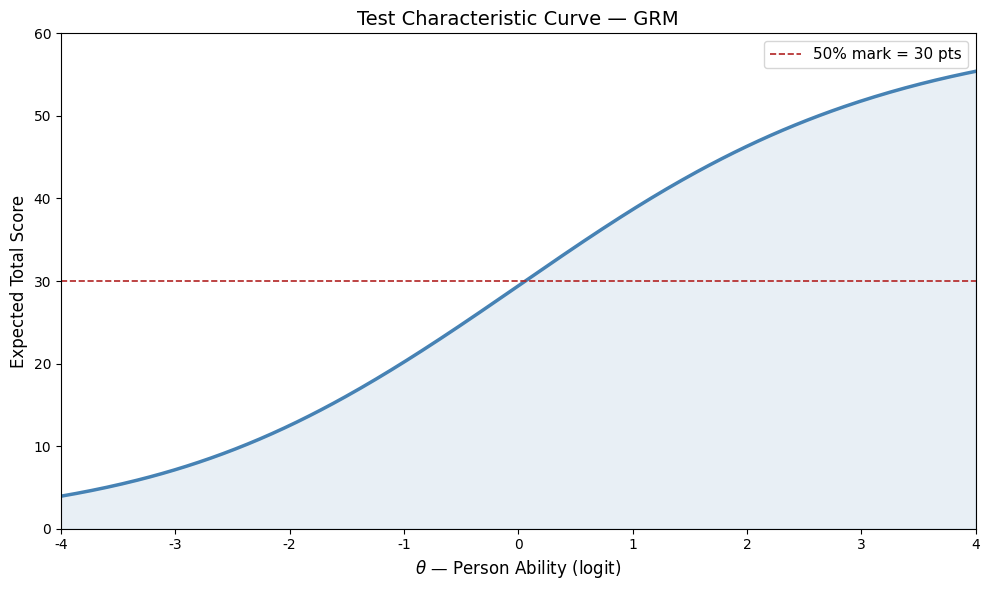

In [8]:
expected_score = np.zeros(len(theta_range))
for i in range(I):
    for t_idx, t in enumerate(theta_range):
        pr = grm_probs(t, a_est[i], b_est[i])
        expected_score[t_idx] += np.dot(np.arange(K), pr)

max_score = I * (K - 1)
fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(theta_range, expected_score, color='steelblue', linewidth=2.5)
ax.fill_between(theta_range, 0, expected_score, alpha=0.12, color='steelblue')
ax.axhline(max_score / 2, color='firebrick', linestyle='--', linewidth=1.2,
           label=f'50% mark = {max_score//2} pts')
ax.set_xlabel('$\\theta$ — Person Ability (logit)', fontsize=12)
ax.set_ylabel('Expected Total Score', fontsize=12)
ax.set_title('Test Characteristic Curve — GRM', fontsize=14)
ax.set_xlim(-4, 4); ax.set_ylim(0, max_score); ax.legend(fontsize=11)
plt.tight_layout()
plt.savefig(os.path.join(tmpdir, 'tcc_grm.png'), dpi=120, bbox_inches='tight')
plt.show()

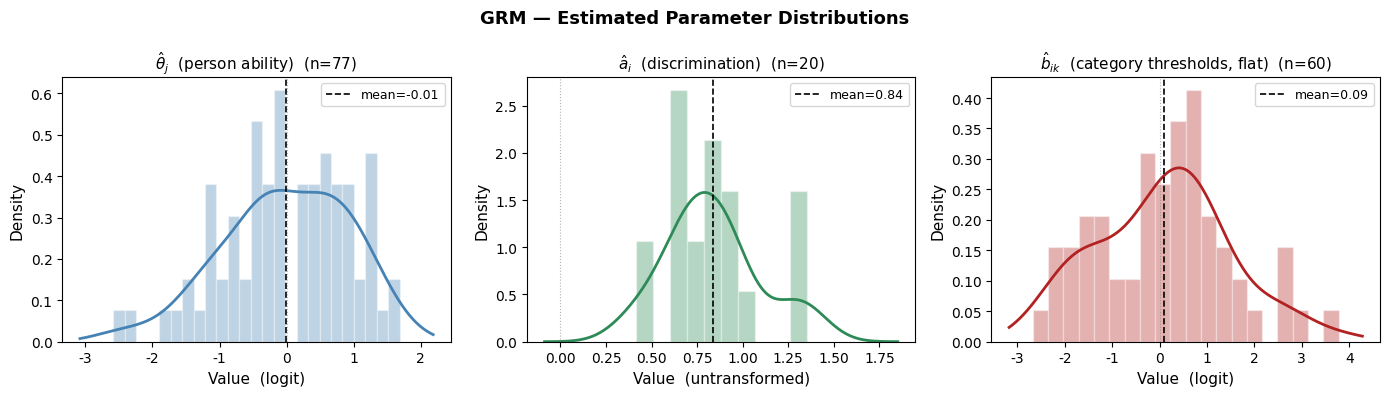

theta     : mean=-0.015  SD=0.925  range=[-2.58, 1.69]
a         : mean=0.837  SD=0.248  range=[0.41, 1.35]
b (flat)  : mean=0.089  SD=1.393  range=[-2.67, 3.78]


In [9]:
# ── Posterior Parameter Density (Logit Scale) ─────────────────────────────
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
fig.suptitle('GRM — Estimated Parameter Distributions', fontsize=13, fontweight='bold')

b_flat = b_est.ravel()

panels = [
    (axes[0], theta_est, r'$\hat{\theta}_j$  (person ability)',         'steelblue',  'logit'),
    (axes[1], a_est,     r'$\hat{a}_i$  (discrimination)',               'seagreen',   'untransformed'),
    (axes[2], b_flat,    r'$\hat{b}_{ik}$  (category thresholds, flat)', 'firebrick',  'logit'),
]

for ax, vals, title, color, unit in panels:
    ax.hist(vals, bins=max(10, len(vals)//3), density=True,
            color=color, alpha=0.35, edgecolor='white')
    if len(vals) >= 3:
        xs = np.linspace(vals.min() - 0.5, vals.max() + 0.5, 300)
        kde = gaussian_kde(vals, bw_method='scott')
        ax.plot(xs, kde(xs), color=color, linewidth=2)
    ax.axvline(vals.mean(), color='black', linestyle='--', linewidth=1.2,
               label=f'mean={vals.mean():.2f}')
    ax.axvline(0, color='gray', linestyle=':', linewidth=0.8, alpha=0.6)
    ax.set_xlabel(f'Value  ({unit})', fontsize=11)
    ax.set_ylabel('Density', fontsize=11)
    ax.set_title(f'{title}  (n={len(vals)})', fontsize=11)
    ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig(os.path.join(tmpdir, 'density_grm.png'), dpi=120, bbox_inches='tight')
plt.show()
for name, vals in [('theta', theta_est), ('a', a_est), ('b (flat)', b_flat)]:
    print(f"{name:10s}: mean={vals.mean():.3f}  SD={vals.std():.3f}  "
          f"range=[{vals.min():.2f}, {vals.max():.2f}]")
